- 【目的】使用GNN预测欺诈，并且与传统ML比较证明GNN在图数据的优势
- 【实现步骤】
1. 数据准备：df转PyG的数据对象（node_fea, edge_idx, tag）；按ts划分train\confirm\test 集；
2. GNN定义与训练（GCN\GAT\GIN\GraphSAGE）交叉验证+早停；类权重+Focal loss处理样本不平衡；
3. 模型选择与调优，验证集的F1分数选择最佳模型、阈值，输出分类报告和混淆矩阵
4. 与传统ML比较，使用相同特征训练LR\RF\SVM，和GNN比较性能结果

根据实际分析结果的几个问题：
1. networkX vs PyG: 前者适合图分析可视化，后者为GNN专门的DL学习框架；
2. 划分数据集，为什么是ts，之前没有做好时序追踪：按时间步划分契合业务场景，模拟未来的预测，防止数据穿越，随机划分会导致泄露；假设一般划分数据集：普通ML中常见的随机划分。但如上所述，在图时序数据中这是错误的。另一种是基于图的划分（如按节点或边采样），但在这个数据集中，时间步是核心属性，时序划分仍是首选。（复刻的时序追踪不明显可能由于抽样和分析粒度差异，参考文档使用0.6采样率模糊了全局长程时序模式）

# 基础DL与 GNN架构

## ML vs DL

- ML: 从特征学习与tag之间关系
- DL: 自动学习特征组合的 具有多层、层层传递信息的黑箱，即神经网络

- 输入层：你的原始特征（166维）。
- 隐藏层：一层层的数学运算（线性变换+非线性激活函数）。每一层都在自动学习上一层特征的更高级、更抽象的表示。比如，第一层可能学到“交易活跃度”的组合，第二层可能学到“与高危账户关联度”的抽象。
- 输出层：根据最终学到的“高级表示”做出预测（欺诈概率）。
- 核心能力：表征学习。DL能自动从原始数据中学习最优的特征表示，免去了大量手工特征工程。

## GNN

核心思路：邻里聚合
- 传统DL（如全连接网络）的问题：每个交易（节点）的166个特征单独输入，完全忽略了这个交易与谁相连这个关键信息。在反欺诈中，一个交易是否可疑，很大程度上取决于它和哪些交易有资金往来。
- GNN的解决方案：在每次特征变换时，不仅考虑节点自身的特征，还聚合其直接邻居的特征。

以GCN为例：
1. 前向传播：对于每个节点，收集其邻居节点的特征，与自身特征进行加权组合（考虑连接强度），然后通过一个可学习的神经网络层（GCNConv）产生该节点新的、更丰富的特征表示。
2. 多层叠加：堆叠多层GCN。第一层后，节点拥有了其“一阶邻居”的信息。第二层后，节点能聚合到“两阶邻居”（的信息。这样，欺诈模式（如一个中心洗钱节点）可以通过图连接进行传播和识别。

多个GNN构架差别在聚合方式不同：
- GCN（图卷积网络）：最经典，像“平均池化”，平等对待所有邻居。
- GAT（图注意力网络）：引入“注意力机制”，让模型学习不同邻居的重要性权重。比如，模型可能认为来自某个特定账户的交易流更重要。
- GraphSAGE：注重归纳学习，通过采样邻居来提升效率，能更好地泛化到未见过的新节点。
- GIN（图同构网络）：理论能力最强，旨在区分不同的图结构。

实现路径：用比特币交易网络（图）的数据，预测节点（交易）是否欺诈。
1. 数据处理 --> 构建PyG Data对象 (为DL模型准备标准的输入数据)
2. 模型定义 --> 选择GNN架构 (如GCN， 设计邻里聚合规则)
3. 训练循环 --> 重复：前向传播 (预测) -> 算损失  -> 反向传播 (归因) -> 优化器更新 (改进)
4. 模型评估 --> 在测试集上用F1、混淆矩阵等指标 (模型打分)
5. 对比实验 --> 用相同的节点特征但不用边，训练随机森林 (做一个对照组，证明图结构特征信息有用)

## GNN_Math

**正向计算函数值；反向计算导数**
1. 前向传播：可导函数σ 复合
2. 反向传播：链式求导（自动微分），目标计算损失函数L 对 每个参数（W权重矩阵）的梯度，更新W减少L
- 链式法则：如果L = f(g(W))，那么∂L/∂W = (∂L/∂f) * (∂f/∂g) * (∂g/∂W)。
在神经网络中，损失L是最终输出，它由很多层复合而成。反向传播从最后层开始，利用链式法则，逐层向前计算每个参数的梯度

信息不丢失：
- 框架（如PyTorch）在前向传播时，不仅计算结果，还会在内存中动态构建一个计算图，记录所有运算（加法、乘法、激活函数等）和中间结果。
- 在反向传播时，框架从这个计算图的终点（损失L）开始，根据每个节点（运算）*局部定义的求导规则*，逆向遍历整个图，*计算所有参数的梯度*。这个过程中，所需的中间值（如前向传播的激活值）会从计算图中获取或重新计算。

**优化器更新参数：梯度下降，使损失最小**
- 随机梯度下降SGD。更新公式：W_new = W_old - η * ΔL，其中η是学习率，ΔL是梯度。沿着梯度方向（函数上升最快方向）的反方向走一小步，以降低函数值。
- 更先进如Adam，在SGD基础引入*动量*和*自适应学习率*
    1. 动量：不仅看当前梯度，还累积过去梯度的指数移动平均，使其在稳定方向加速，在震荡方向减速，帮助更快收敛并减少震荡。
    2. 自适应学习率：为每个参数维护一个学习率，对于频繁更新的参数（梯度大）使用较小的学习率，对于不频繁更新的参数（梯度小）使用较大的学习率。这有助于处理稀疏或尺度不一的特征

## 调参与实验

默认Adam参数，调整学习率
- 学习率（lr）：最重要的超参数。通常从经典值开始尝试（如Adam用3e-4）。观察训练损失曲线：若损失剧烈震荡不降，则lr太大；若下降极其缓慢，则lr可能太小。常用策略是使用学习率调度器（如每N个epoch衰减）。
- 权重衰减（weight_decay）：即L2正则化系数，用于惩罚大权重，防止过拟合。通常设为一个小值（如1e-5）。
- 动量参数（betas）：Adam中的beta1（一阶矩估计的衰减率）和beta2（二阶矩估计的衰减率）。绝大多数情况下，使用默认值（0.9和0.999）即可，无需调整。

训练停止、自动化：
- 一个epoch：所有数据进模型；一次迭代：同一批batch处理
- 自动停止（早停）：在每个epoch结束后，在验证集上计算评估指标（如F1分数）。如果连续patience个epoch（如10个）该指标没有提升，则停止训练，并自动加载验证集指标最好的那个epoch的模型权重。这是防止过拟合、自动化模型选择的关键。
- 手动设置：人工设定的最大epoch数、早停的patience值、学习率大小等，这些是超参数，需要根据经验或实验来设置。
- 一次训练，一次验证，交替进行。在每个训练epoch后，模型在验证集上前向传播一次（不反向传播，不更新参数），计算评估指标。这用于监控模型在未见数据上的泛化能力，并决定是否早停。

F1业务理解：调和平均数，在不均衡数据集的综合表现
精准率：预测为欺诈与实际情况的比例，准确度——高精度误报少，可能有遗漏
召回率：实际欺诈中，被正确预测出来的比例，命中率——高找回遗漏少，精度有误

# 调整Phase 6 增加基于本地CPU的小数据子集

1. 采样
- 【本地】验证代码跑通模型，损失函数可正常下降
- 采样原则：微型图保留核心数据结构（node\edge\fea\label）
- 采样实操：结合业务逻辑按时间步截取，如前ts5（无意义则可随机采样0.01的node，根据其ID筛选出入的边确保连通）
- 采样检查：确保含标签的节点
2. 隐藏层降维
- 定义原则：大幅减少model参数量，加速前向、反向传播计算
- 定义实操：隐层维度设置16\32


区分隐藏层 层数和维度：
- 层数：信息传播深度/转换次数；GNN常用2-3层，即二阶/三阶邻居进行聚合。其他类似全连接数据常用经验公式：（输入层+输出层）节点*2/3
- 维度/宽度：每一个隐藏层输出的特征向量长度，该层有几个神经元/特征通道。越大越学习复杂模式，但更容易过拟合、计算开销增加

1. 第一优先级（固定架构，调其他）：首先，将层数固定为2，隐藏层维度固定为128（或你选的中值），然后去调整学习率、损失函数权重等对训练动态影响更大的超参数。
2. 第二优先级（调整架构）：当找到一组较好的训练超参数后，再回头来微调架构：
调整维度：在[64, 128, 256]中寻找最佳值。
调整层数：比较2层和3层（可以保持总参数量近似，例如2层128维 对比 3层64维）。

维度幂次方：内存对齐，硬件读取内存按块；GPU线程对齐

# code

冲突？

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'  # 允许重复的OpenMP运行时
os.environ['OMP_NUM_THREADS'] = '1'  # 限制OpenMP线程数

## 1 数据采样和处理

In [3]:
import pandas as pd
import numpy as np

import torch
from torch_geometric.data import Data
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv  #核心GCN层
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score
# metrics包括F1等指标计算
import matplotlib.pyplot as plt # 指标可视化
import time

d:\software\anaconda3\envs\gnn\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
from sklearn.metrics import precision_recall_fscore_support

In [4]:
os.getcwd()

'd:\\01_project\\2602-GNN\\notebooks'

In [5]:
PROJECT_ROOT = r'd:\01_project\2602-GNN'
DATA_DIR = os.path.join(PROJECT_ROOT, 'data', 'elliptic_bitcoin_dataset') 

1)加载数据+列名重命名

In [6]:
# 3份数据，注意表头，改列明，采样取ts前5，打印检查
df_classes = pd.read_csv(os.path.join(DATA_DIR, 'elliptic_txs_classes.csv'), index_col='txId')
df_edges = pd.read_csv(os.path.join(DATA_DIR, 'elliptic_txs_edgelist.csv'))
df_features = pd.read_csv(os.path.join(DATA_DIR, 'elliptic_txs_features.csv'), header=None)

col_names = ['txId', 'Time_step'] + [f'local_{i}' for i in range(1, 94)] + [f'aggr_{i}' for i in range(1, 73)]
df_features.columns = col_names
df_features.set_index('txId', inplace=True)

print(f"类别数据形状: {df_classes.shape}")
print(f"边数据形状: {df_edges.shape}")
print(f"特征数据形状: {df_features.shape}")
print(f"特征数据前5列名: {df_features.columns[:5].tolist()}")
print(f"时间步范围: {df_features['Time_step'].min()} 到 {df_features['Time_step'].max()}")

类别数据形状: (203769, 1)
边数据形状: (234355, 2)
特征数据形状: (203769, 166)
特征数据前5列名: ['Time_step', 'local_1', 'local_2', 'local_3', 'local_4']
时间步范围: 1 到 49


2）node表创建，准备训练的标签

In [7]:
# 1. 确保索引类型为字符串，便于安全合并
df_features.index = df_features.index.astype(str)
df_classes.index = df_classes.index.astype(str)

# 2. 合并特征与标签
df_nodes = df_features.merge(df_classes, how='left', left_index=True, right_index=True)
# 填充可能的空值并映射标签（实际无空值）
df_nodes['class'] = df_nodes['class'].fillna('unknown')
df_nodes['class'] = df_nodes['class'].replace({'unknown': 3, '1': 1, '2': 2}).astype(int)
# 原始类别是123，映射训练为0/1/-1
# 3. 创建GNN训练标签列：Illicit->0, Licit->1, Unknown->-1
df_nodes['gnn_label'] = df_nodes['class'].replace({1: 0, 2: 1, 3: -1})

print(f"节点主表 形状: {df_nodes.shape}")
print("原始类别分布:")
print(df_nodes['class'].value_counts().sort_index())
print("\nGNN训练标签分布:")
print(df_nodes['gnn_label'].value_counts().sort_index())
# 必须验证标签的分布和正确映射

节点主表 形状: (203769, 168)
原始类别分布:
class
1      4545
2     42019
3    157205
Name: count, dtype: int64

GNN训练标签分布:
gnn_label
-1    157205
 0      4545
 1     42019
Name: count, dtype: int64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_16920\1659082567.py:12: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_nodes['gnn_label'] = df_nodes['class'].replace({1: 0, 2: 1, 3: -1})


3）基于ts前5截取业务子图

In [8]:
# 定义截取的时间范围，取前5个时间步
START_TS = 1
END_TS = 5

# 截取范围内所有node，索引构建集合？
df_nodes_sub = df_nodes[(df_nodes['Time_step']>=START_TS) & (df_nodes['Time_step']<=END_TS)]
sampled_node_ids = set(df_nodes_sub.index)
print(f'截取的node数量：{len(sampled_node_ids)}')

# 截取边，保留两端都在采样节点set中的边
df_edges['txId1'] = df_edges['txId1'].astype(str)
df_edges['txId2'] = df_edges['txId2'].astype(str)

df_edges_sub = df_edges[
    df_edges['txId1'].isin(sampled_node_ids) & 
    df_edges['txId2'].isin(sampled_node_ids)
].copy()
print(f"截取到边数: {len(df_edges_sub)}")

# 4. 为边表添加时间步信息（取自源节点txId1）
df_edges_temporal_sub = df_edges_sub.merge(
    df_nodes_sub[['Time_step']],
    how='left',
    left_on='txId1',
    right_index=True
).rename(columns={'Time_step': 'time_step'})

# 5. 重要检查：确保截取的子图中包含训练所需的两种已知标签
labels_in_sub = df_nodes_sub['gnn_label'].unique()
print(f"\n[业务子图统计]")
print(f"  节点时间步范围: {df_nodes_sub['Time_step'].min()} 到 {df_nodes_sub['Time_step'].max()}")
print(f"  子图内存在的标签类型: {labels_in_sub}")
print(f"  已知标签(0/1)节点数: {(df_nodes_sub['gnn_label'] != -1).sum()}")

截取的node数量：31541
截取到边数: 39524

[业务子图统计]
  节点时间步范围: 1 到 5
  子图内存在的标签类型: [-1  1  0]
  已知标签(0/1)节点数: 7865


4）构建PyG Data对象

In [9]:
# 1. node特征矩阵 X
# 从 df_nodes_sub 中选出166个特征列
feature_columns = [col for col in df_nodes_sub.columns if col.startswith('local_') or col.startswith('aggr_')]
# 检查特征选择正确165
print(f"特征列数量: {len(feature_columns)}， 例如: {feature_columns[:3]}")
x_np = df_nodes_sub[feature_columns].values.astype(np.float32)  # 使用float32节省内存/算力
x = torch.from_numpy(x_np)
print(f"节点特征矩阵 x 形状: {x.shape} (应为 [节点数, 166])")

特征列数量: 165， 例如: ['local_1', 'local_2', 'local_3']
节点特征矩阵 x 形状: torch.Size([31541, 165]) (应为 [节点数, 166])


In [10]:
# 2. node标签向量 y：torch.from_numpy要求int64，列向量
y_np = df_nodes_sub['gnn_label'].values.astype(np.int64)
y = torch.from_numpy(y_np)
print(f'node标签 y 形状：{y.shape}')

node标签 y 形状：torch.Size([31541])


In [11]:
# 准备索引edge_index，PyG要求2行，第一行源节点索引，第二行目标节点索引
# 1. 为子图中的每个节点分配一个从0开始的连续索引
node_id_to_idx = {node_id: idx for idx, node_id in enumerate(df_nodes_sub.index)}
print(f"已创建节点ID到索引的映射，共 {len(node_id_to_idx)} 项。")

# 2. 将边列表中的节点ID映射为上面创建的连续索引
# 注意：df_edges_sub 中的 'txId1' 和 'txId2' 应为字符串类型
edge_source_idx = df_edges_sub['txId1'].map(node_id_to_idx)
edge_target_idx = df_edges_sub['txId2'].map(node_id_to_idx)

# 检查索引映射正确，无遗漏
if edge_source_idx.isnull().any() or edge_target_idx.isnull().any():
    raise ValueError("存在无法映射的节点ID")
else:
    print(edge_source_idx.head())

已创建节点ID到索引的映射，共 31541 项。
0    0
1    2
2    4
3    6
4    8
Name: txId1, dtype: int64


### PyTorch张量，PyG Data对象

In [12]:
edge_source_idx_tensor = torch.from_numpy(edge_source_idx.values.astype(np.int64))
edge_target_idx_tensor = torch.from_numpy(edge_target_idx.values.astype(np.int64))
edge_index = torch.stack([edge_source_idx_tensor, edge_target_idx_tensor])
print(f'edge_index 形状：{edge_index.shape}')

edge_index 形状：torch.Size([2, 39524])


In [13]:
data = Data(x=x, edge_index=edge_index, y=y)

### 划分训练、验证集

本地测试：全局为ts前5，训练用ts1-3，验证用ts4-5；布尔掩码设置中断end start

In [14]:
TRAIN_TS_END = 3
VAL_TS_START =4

time_steps = df_nodes_sub['Time_step'].values
# 布尔掩码
train_time_mask = time_steps <= TRAIN_TS_END
val_time_mask = (time_steps >= VAL_TS_START) & (time_steps <= 5)

In [15]:
# 布尔数组numpy也要转为Pytorch张量，再到Data对象
data.train_mask = torch.from_numpy(train_time_mask)
data.val_mask = torch.from_numpy(val_time_mask)
print(f'训练节点数：{data.train_mask.sum().item()}')
print(f'验证节点数：{data.val_mask.sum().item()}')

训练节点数：19045
验证节点数：12496


### 数据集划分检查

训练/验证集都必须包含已知标签01的node

In [16]:
train_labels = data.y[data.train_mask]
val_labels = data.y[data.val_mask]

train_known = (train_labels != -1)
val_known = (val_labels != -1)

print(f"  训练集中已知标签(0/1)节点数: {train_known.sum().item()}")
print(f"  验证集中已知标签(0/1)节点数: {val_known.sum().item()}")

  训练集中已知标签(0/1)节点数: 4543
  验证集中已知标签(0/1)节点数: 3322


## 2 GCN定义、训练、验证

### 2.1 2层GCN定义、加权损失函数、评估函数、模型初始化

把GCN、损失、评估分别用类、函数包裹

1. GCN类

In [17]:
class GCN(torch.nn.Module):
    """两层图卷积网络，dropout"""
    def __init__(self, num_node_features, hidden_channels, num_classes, dropout=0.5):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(num_node_features, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, num_classes)
        self.dropout = dropout

    def forward(self, data):
        # 使用已有的 data 对象的 x 和 edge_index
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)  # 只在训练时dropout
        x = self.conv2(x, edge_index)
        return x  # 输出 raw logits

2. 类别权重计算

In [18]:
# 训练集中的已知标签样本（即 data.y != -1 且 data.train_mask 为真）来计算权重。
print("\n 计算类别权重")
# 获取训练集中已知标签的索引
train_known_idx = (data.y != -1) & data.train_mask
train_labels_known = data.y[train_known_idx]

# 统计训练集中每个类别的样本数
unique_labels, counts = torch.unique(train_labels_known, return_counts=True)
print(f"  训练集已知标签分布 - 类别 {unique_labels.tolist()}: 数量 {counts.tolist()}")

# 计算权重：总样本数 / (类别数 * 该类样本数)，使少数类获得更高权重
n_samples = counts.sum().item()
n_classes = len(unique_labels)
class_weights = n_samples / (n_classes * counts.float())

print(f"  计算出的类别权重: {class_weights.tolist()}")

# 将权重转换为Tensor
class_weight_tensor = class_weights.to(data.x.dtype)
train_labels_known = data.y[train_known_idx]


 计算类别权重
  训练集已知标签分布 - 类别 [0, 1]: 数量 [46, 4497]
  计算出的类别权重: [49.380435943603516, 0.5051144957542419]


In [ ]:
# 权重转为Tensor
# ---------- 3. 定义评估函数 ----------
def evaluate(model, data, mask):
    """
    在指定掩码的节点上评估模型性能。
    返回: (平均损失, 准确率, F1分数, 预测标签, 真实标签)
    """
    model.eval()
    with torch.no_grad():
        out = model(data)  # 前向传播，得到所有节点的logits
        # 只计算掩码内且标签已知的样本
        eval_mask = mask & (data.y != -1)
        if eval_mask.sum() == 0:
            return None, None, None, None, None
        loss = F.cross_entropy(out[eval_mask], data.y[eval_mask], weight=class_weight_tensor).item()
        pred = out.argmax(dim=1)  # 获取预测类别
        y_true = data.y[eval_mask].cpu().numpy()
        y_pred = pred[eval_mask].cpu().numpy()
        acc = accuracy_score(y_true, y_pred)
        #  !average='binary'默认把标签1作为正类，且不适合不均衡数据，建议改为average='weighted'或'macro'
        f1_macro= f1_score(y_true, y_pred, average='macro') 
        # 增加欺诈类的精确、召回、F1指标计算
        precision, recall, f1_per_class, _ = precision_recall_fscore_support(
            y_true, y_pred, labels=[0, 1], average=None, zero_division=0
        )

        return loss, acc, f1_macro, y_pred, y_true,(precision[0],recall[0],f1_per_class[0])


In [20]:
# ---------- 4. 设置模型超参数与初始化 ----------
# 超参数参考文档3的常用值。
HIDDEN_CHANNELS = 128   # 隐藏层维度，2的幂次，介于输入(166)和输出(2)之间
DROPOUT = 0.5          # Dropout率，常用值
LEARNING_RATE = 0.01   # 学习率，文档3中GCN的初始学习率
EPOCHS = 150           # 最大训练轮数，预计会早停
PATIENCE = 20          # 早停耐心值，连续PATIENCE轮验证F1未提升则停止
# 新增NUM_CLASSES作为data的属性，二分类问题直接用2不用len
NUM_CLASSES = 2
print("\n[模型与超参数初始化]")
print(f"  隐藏层维度: {HIDDEN_CHANNELS}")
print(f"  Dropout率: {DROPOUT}")
print(f"  初始学习率: {LEARNING_RATE}")
print(f"  最大训练轮数: {EPOCHS}")
print(f"  早停值: {PATIENCE}")
print(f"  类别数: {NUM_CLASSES}")


[模型与超参数初始化]
  隐藏层维度: 128
  Dropout率: 0.5
  初始学习率: 0.01
  最大训练轮数: 150
  早停值: 20
  类别数: 2


In [24]:
# 每次训练前需要打印好设施、超参数、权重等信息，便于调试和记录
# 实例化模型、损失函数、优化器
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"  使用设备: {device}")

model = GCN(
    num_node_features=data.num_node_features,  
    hidden_channels=HIDDEN_CHANNELS,
    num_classes=NUM_CLASSES, 
    dropout=DROPOUT
).to(device)

# 将data移到设备（注意：edge_index等也需要移动）
data = data.to(device)
class_weight_tensor = class_weight_tensor.to(device)

# 定义优化器：Adam
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
# 损失函数将在训练循环中直接调用 F.cross_entropy 并传入 weight 参数

print(f"  模型参数量: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("模型、损失函数、优化器初始化完成。")

  使用设备: cpu
  模型参数量: 21,506
模型、损失函数、优化器初始化完成。


### 2.2 训练+早停

In [26]:
print("\n[开始训练循环]")
print("-" * 60)

# 初始化跟踪变量
train_losses = []
val_losses = []
val_f1s = []
best_val_f1_macro = 0.0
best_epoch = 0
early_stop_counter = 0
best_model_state_dict = None

start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    # ---------- 训练模式 ----------
    model.train()
    optimizer.zero_grad()
    
    # 前向传播
    out = model(data)
    # 计算训练损失：只针对训练集且标签已知的节点
    train_mask_known = data.train_mask & (data.y != -1)
    loss = F.cross_entropy(out[train_mask_known], data.y[train_mask_known], weight=class_weight_tensor)
    
    # 反向传播与优化
    loss.backward()
    optimizer.step()
    
    train_loss = loss.item()
    train_losses.append(train_loss)
    
    # ---------- 验证模式 ----------
    val_loss, val_acc, val_f1_macro, _, _, val_illicit_metrics = evaluate(model, data, data.val_mask)
    if val_loss is None:  # 验证集没有已知标签样本
        print(f"警告: 第 {epoch} 轮，验证集无已知标签样本，无法计算指标。")
        break
    val_losses.append(val_loss)
    val_f1s.append(val_f1_macro)
    
    # ---------- 早停与模型保存逻辑 ----------
    if val_f1_macro > best_val_f1_macro:
        best_val_f1_macro = val_f1_macro
        best_epoch = epoch
        early_stop_counter = 0
        # 保存最佳模型状态字典（与文档3保存 .pt 文件的方式一致）
        best_model_state_dict = model.state_dict().copy()
        # 欺诈指标保存
        best_illicit_precision, best_illicit_recall, best_illicit_f1 = val_illicit_metrics
    else:
        early_stop_counter += 1
    
    # ---------- 打印进度 ----------
    # 在逻辑循环中修改打印信息
    if epoch % 10 == 0 or epoch == 1 or early_stop_counter == 0:
        # 获取训练集的欺诈类指标
        model.eval()
        with torch.no_grad():
            train_out = model(data)
            train_pred = train_out.argmax(dim=1)
            train_mask_known = data.train_mask & (data.y != -1)
            y_true_train = data.y[train_mask_known].cpu().numpy()
            y_pred_train = train_pred[train_mask_known].cpu().numpy()
            
            train_acc = accuracy_score(y_true_train, y_pred_train)
            # 计算训练集的Macro F1和欺诈类指标
            train_f1_macro = f1_score(y_true_train, y_pred_train, average='macro')
            train_precision, train_recall, train_f1_per_class, _ = precision_recall_fscore_support(
                y_true_train, y_pred_train, labels=[0, 1], average=None, zero_division=0
            )
        
        print(f'Epoch {epoch:03d} | '
            f'Train Loss: {train_loss:.4f} | Train Macro F1: {train_f1_macro:.4f} | '
            f'Val Loss: {val_loss:.4f} | Val Macro F1: {val_f1_macro:.4f} | '
            f'Best Macro F1: {best_val_f1_macro:.4f} (Epoch {best_epoch})')
        print(f'           | Train Illicit - P: {train_precision[0]:.4f}, R: {train_recall[0]:.4f}, F1: {train_f1_per_class[0]:.4f}')
        print(f'           | Val Illicit   - P: {val_illicit_metrics[0]:.4f}, R: {val_illicit_metrics[1]:.4f}, F1: {val_illicit_metrics[2]:.4f}')
        # ---------- 早停检查 ----------
        if early_stop_counter >= PATIENCE:
            print(f'\n早停在 epoch {epoch} 停止训练。')
            print(f'   验证集F1分数连续 {PATIENCE} 轮未从 {best_val_f1:.4f} 提升。')
            break

# 训练结束，加载最佳模型
if best_model_state_dict is not None:
    model.load_state_dict(best_model_state_dict)
    print(f'\n训练完成。加载了第 {best_epoch} 轮的最佳模型 (验证集F1: {best_val_f1:.4f})。')
else:
    print('\n  训练完成，但未保存到最佳模型状态。')

total_time = time.time() - start_time
print(f'总训练时间: {total_time:.2f} 秒')


[开始训练循环]
------------------------------------------------------------
Epoch 001 | Train Loss: 0.7572 | Train Macro F1: 0.3848 | Val Loss: 0.5565 | Val Macro F1: 0.3766 | Best Macro F1: 0.3766 (Epoch 1)
           | Train Illicit - P: 0.0231, R: 1.0000, F1: 0.0452
           | Val Illicit   - P: 0.0231, R: 0.9211, F1: 0.0450
Epoch 002 | Train Loss: 0.5084 | Train Macro F1: 0.4984 | Val Loss: 0.5337 | Val Macro F1: 0.4955 | Best Macro F1: 0.4955 (Epoch 2)
           | Train Illicit - P: 0.0505, R: 0.9348, F1: 0.0959
           | Val Illicit   - P: 0.0483, R: 0.7895, F1: 0.0910
Epoch 003 | Train Loss: 0.4112 | Train Macro F1: 0.5535 | Val Loss: 0.6200 | Val Macro F1: 0.5367 | Best Macro F1: 0.5367 (Epoch 3)
           | Train Illicit - P: 0.0856, R: 0.8261, F1: 0.1551
           | Val Illicit   - P: 0.0702, R: 0.6316, F1: 0.1263
Epoch 004 | Train Loss: 0.3443 | Train Macro F1: 0.5650 | Val Loss: 0.6584 | Val Macro F1: 0.5473 | Best Macro F1: 0.5473 (Epoch 4)
           | Train Illicit - 

结果：在第一轮的F1最高？损失L在训练下降快，但在验证小范围震荡

数据泄露or评估问题？可能在训练集过拟合；结合业务场景，欺诈模式在时间范围剧烈变化

### 2.3 可视化检查报告

检查欺诈的精确、召回率，样本数量划分不平衡？

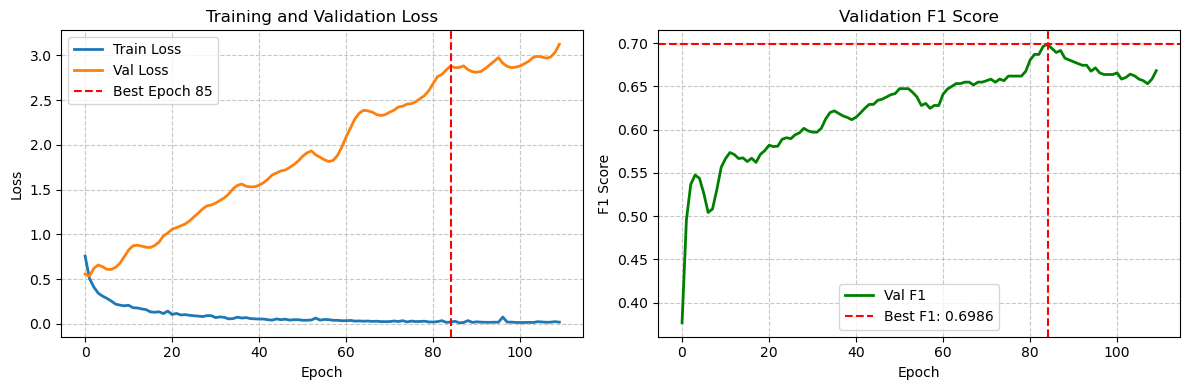

In [27]:
# ---------- 1. 绘制训练曲线 ----------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 损失曲线
axes[0].plot(train_losses, label='Train Loss', linewidth=2)
axes[0].plot(val_losses, label='Val Loss', linewidth=2)
axes[0].axvline(x=best_epoch-1, color='r', linestyle='--', label=f'Best Epoch {best_epoch}')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# F1分数曲线
axes[1].plot(val_f1s, label='Val F1', linewidth=2, color='green')
axes[1].axhline(y=best_val_f1_macro, color='r', linestyle='--', label=f'Best F1: {best_val_f1_macro:.4f}')
axes[1].axvline(x=best_epoch-1, color='r', linestyle='--')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Validation F1 Score')
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [30]:
# ---------- 2. 在验证集上进行最终评估 ----------
print("最终模型在验证集上的评估结果")
print("="*60)

model.eval()
val_loss, val_acc, val_f1_macro, y_pred, y_true, illicit_metrics = \
        evaluate(model, data, data.val_mask)

if y_true is not None:
    print(f"验证集样本数: {len(y_true)}")
    print(f"验证集损失: {val_loss:.4f}")
    print(f"验证集准确率: {val_acc:.4f}")
    print(f"验证集F1分数: {val_f1_macro:.4f}")
    
    # 输出分类报告，与文档3的 `classification_report` 一致
    print("\n分类报告 (Classification Report):")
    print(classification_report(y_true, y_pred, target_names=['Illicit (0)', 'Licit (1)']))
    
    # 可以在此添加混淆矩阵绘制，如需要
    # from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    # cm = confusion_matrix(y_true, y_pred)
    # disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Illicit', 'Licit'])
    # disp.plot()
    # plt.title('Confusion Matrix on Validation Set')
    # plt.show()
else:
    print("验证集无已知标签样本，无法评估。")


最终模型在验证集上的评估结果
验证集样本数: 3322
验证集损失: 3.1241
验证集准确率: 0.9828
验证集F1分数: 0.6681

分类报告 (Classification Report):
              precision    recall  f1-score   support

 Illicit (0)       0.31      0.39      0.34        38
   Licit (1)       0.99      0.99      0.99      3284

    accuracy                           0.98      3322
   macro avg       0.65      0.69      0.67      3322
weighted avg       0.99      0.98      0.98      3322



In [ ]:
# 在逻辑块4/4中修改最终评估
print("\n" + "="*60)
print("最终模型在验证集上的评估结果")
print("="*60)

model.eval()
val_loss, val_acc, val_f1_macro, y_pred, y_true, illicit_metrics = evaluate(model, data, data.val_mask)

if y_true is not None:
    val_precision, val_recall, val_f1_illicit = illicit_metrics
    
    print(f"验证集样本数: {len(y_true)}")
    print(f"验证集损失: {val_loss:.4f}")
    print(f"验证集准确率: {val_acc:.4f}")
    print(f"验证集Macro F1: {val_f1_macro:.4f}")
    print(f"欺诈类(0) - 精确率: {val_precision:.4f}, 召回率: {val_recall:.4f}, F1: {val_f1_illicit:.4f}")
    
    # 输出详细的分类报告
    print("\n详细分类报告:")
    print(classification_report(y_true, y_pred, target_names=['Illicit (0)', 'Licit (1)'], digits=4))
    
    # 添加混淆矩阵可视化
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Illicit', 'Licit'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f'Confusion Matrix (Epoch {best_epoch})')
    plt.show()

验证集混淆矩阵:
           预测为0  预测为1
真实为0:       21       17
真实为1:      152     3132

各类别的详细指标:
Illicit(0) - 精确率: 0.1214, 召回率: 0.5526, F1: 0.1991, 样本数: 38
Licit(1)   - 精确率: 0.9946, 召回率: 0.9537, F1: 0.9737, 样本数: 3284

宏平均F1 (Macro F1): 0.5864
加权平均F1 (Weighted F1): 0.9649


第1次log结果：
- 验证集样本数: 3322
验证集损失: 0.8612
验证集准确率: 0.9491
验证集F1分数: 0.9737
- 问题：过拟合（样本量导致，忽略）、数据泄露（时间步3和4划分是否还有边连接），F1计算有问题（默认变迁1为正类）
- 为什么第1轮的验证F1（主要反映Licit类）那么高？
因为初始随机权重下，模型倾向于预测多数类（Licit），而验证集中Licit类占绝大多数（3284/3322=98.8%），所以初始准确率很高，F1也很高。
随着训练进行，模型在加权损失函数的影响下，开始尝试拟合Illicit类，这导致对Licit类的分类性能略有下降，所以验证F1下降。
因此，我们需要调整评估指标，以Illicit类的F1（或宏平均F1）作为早停标准，而不是默认以标签1为正类的F1。
- 具体代码错误：
    - f1_score调用average="binary"默认标签1为正类；
    - 验证集潜在数据泄露：存在边从验证node指向训练node，模型训练可能间接看到验证集信息？
    - 评估指标选择错误：极度不平衡欺诈检测，不用binaryF1会偏向多数，准确率也被多数类支配，应该使用MacroF1和欺诈类的召回、精确率